### HW6

#### Packages

In [11]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder

#### Loading Data   

In [12]:
data = pd.read_csv('HW06_data.csv')
X = data.drop('Y', axis=1)
y = data['Y']
#print (X.shape, y.shape)
#print (X.head())
print (y.value_counts())

Y
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64


#### Preprocessing

In [13]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
#print (x_train.shape, y_train.shape)
#print (x_test.shape, y_test.shape)
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
CLASS_NAMES = encoder.classes_
print(pd.DataFrame(y_train).value_counts())
print(pd.DataFrame(y_test).value_counts())


0
1    53
0    44
2    36
Name: count, dtype: int64
0
1    18
0    15
2    12
Name: count, dtype: int64


Optimization

In [14]:
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis()
}
scores_dict = {}
for name, model in models.items():
    scores = cross_val_score(model, x_train, y_train, cv=kfold, scoring='f1_weighted')
    scores_dict[name] = scores.mean()
    print(f"{name} - Cross-validation scores: {scores}")
    print(f"{name} - Mean CV score: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

sorted_models = sorted(scores_dict.items(), key=lambda item: item[1], reverse=True)
print("Model Rankings:")
for rank, (model_name, score) in enumerate(sorted_models, start=1):
    print(f"{rank}. {model_name}: {score:.4f}")

LogisticRegression - Cross-validation scores: [0.88747795 0.88790929 0.85354126 0.8088774  0.96175393]
LogisticRegression - Mean CV score: 0.8799 (+/- 0.1002)
LDA - Cross-validation scores: [0.88747795 0.8117284  0.81798942 0.88396897 0.92164404]
LDA - Mean CV score: 0.8646 (+/- 0.0854)
QDA - Cross-validation scores: [0.77777778 0.69474969 0.62457912 0.76815342 0.80723982]
QDA - Mean CV score: 0.7345 (+/- 0.1325)
Model Rankings:
1. LogisticRegression: 0.8799
2. LDA: 0.8646
3. QDA: 0.7345


#### Training and Testing

In [15]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis()
}
qda=models['QDA'].fit(x_train, y_train)
LR =models['LogisticRegression'].fit(x_train, y_train)
lda=models['LDA'].fit(x_train, y_train)

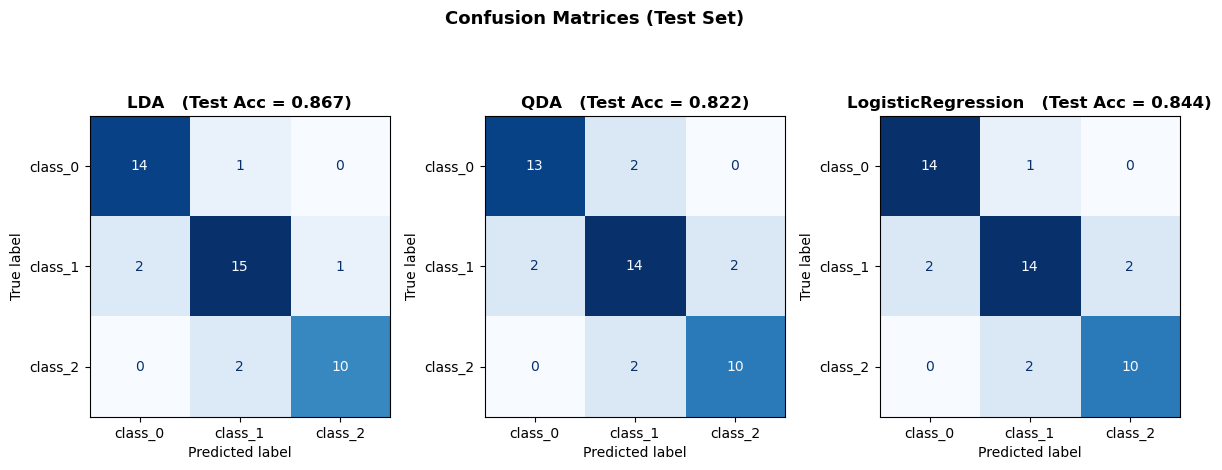

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
fig.suptitle('Confusion Matrices (Test Set)', fontsize=13, fontweight='bold')

for ax, clf, name in zip(axes, [lda, qda, LR], ['LDA', 'QDA', 'LogisticRegression']):
    cm = confusion_matrix(y_test, clf.predict(x_test))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}   (Test Acc = {clf.score(x_test, y_test):.3f})', fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300)
plt.show()

In [17]:
print(f'Training samples : {len(x_train)}')
print(f'Test samples     : {len(x_test)}')
print()
print(f'LDA  train | test accuracy: {lda.score(x_train, y_train):.4f}  |  {lda.score(x_test, y_test):.4f}')
print(f'QDA  train | test accuracy: {qda.score(x_train, y_train):.4f}  |  {qda.score(x_test, y_test):.4f}')
print(f'LR  train | test accuracy: {LR.score(x_train, y_train):.4f}  |  {LR.score(x_test, y_test):.4f}')

Training samples : 133
Test samples     : 45

LDA  train | test accuracy: 0.9023  |  0.8667
QDA  train | test accuracy: 0.9624  |  0.8222
LR  train | test accuracy: 0.9323  |  0.8444


In [18]:
for clf, name in [(lda, 'LDA'), (qda, 'QDA'), (LR, 'LogisticRegression')]:
    print('-' * 55)
    print(f'  {name} — Classification Report')
    print('-' * 55)
    print(classification_report(y_test, clf.predict(x_test),
                                 target_names=CLASS_NAMES))

-------------------------------------------------------
  LDA — Classification Report
-------------------------------------------------------
              precision    recall  f1-score   support

     class_0       0.88      0.93      0.90        15
     class_1       0.83      0.83      0.83        18
     class_2       0.91      0.83      0.87        12

    accuracy                           0.87        45
   macro avg       0.87      0.87      0.87        45
weighted avg       0.87      0.87      0.87        45

-------------------------------------------------------
  QDA — Classification Report
-------------------------------------------------------
              precision    recall  f1-score   support

     class_0       0.87      0.87      0.87        15
     class_1       0.78      0.78      0.78        18
     class_2       0.83      0.83      0.83        12

    accuracy                           0.82        45
   macro avg       0.83      0.83      0.83        45
weighted 

C:\Users\tjmel\AppData\Local\Temp\ipykernel_4480\3661949215.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


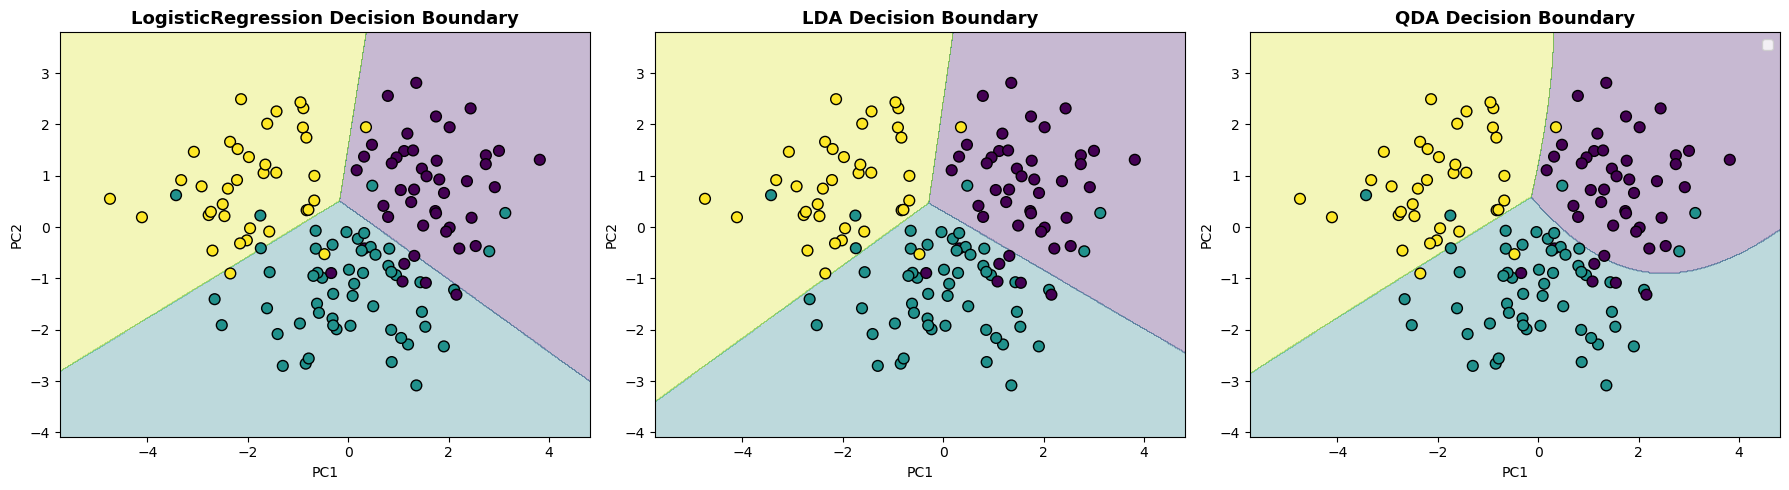

In [ ]:
from sklearn.decomposition import PCA   

pca = PCA(n_components=2)
x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)

# Fit models on PCA-transformed data
models_pca = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42).fit(x_train_pca, y_train),
    'LDA': LinearDiscriminantAnalysis().fit(x_train_pca, y_train),
    'QDA': QuadraticDiscriminantAnalysis().fit(x_train_pca, y_train)
}

# Create meshgrid
h = 0.02
x_min, x_max = x_train_pca[:, 0].min() - 1, x_train_pca[:, 0].max() + 1
y_min, y_max = x_train_pca[:, 1].min() - 1, x_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
grid = np.c_[xx.ravel(), yy.ravel()]

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, model) in zip(axes, models_pca.items()):
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    scatter = ax.scatter(x_train_pca[:, 0], x_train_pca[:, 1], c=y_train, cmap='viridis', edgecolor='k', s=60)
    ax.set_title(f'{name} Decision Boundary', fontsize=13, fontweight='bold')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
#fig.colorbar(scatter, ax=axes, label='Class Label')
plt.tight_layout()
plt.legend()
plt.show()
